### Modalities

| Modality | Embedding | What it encodes | Tokens |
|:---------|:----------|:----------------|:-------|
| **ESM2** | 1280-d mean-pooled | *Intrinsic* biochemistry — what amino acids are present and how they interact locally | 8 |
| **SBERT** | 384-d | Semantic meaning of textual annotations | 4 |
| **TF-IDF** | sparse → 128-d LSA | Keyword/GO vocabulary bag-of-words signal | 4 |
| **MSA** | pairwise-cosine → 64-d PCA | *Relational* — evolutionary neighbourhood, how similar this protein is to every other GPCR in the dataset | 4 |

> **Why both ESM2 and MSA if both come from sequences?**
> They encode **orthogonal views** of the same proteins.
> ESM2 (per-token transformer) answers *"what does this sequence look like biochemically?"* — it is an absolute representation of a single sequence in isolation.
> The MSA similarity profile answers *"where does this protein sit in the GPCR family tree?"* — it is a **relational** representation: after PCA, each dimension captures a principal axis of family-membership variation across all proteins.  This is exactly the information a multiple-sequence alignment provides (co-variation patterns, conservation scores, subfamily distances), obtained here without needing an external aligner by leveraging the pre-computed ESM2 cosine similarities.

### Output Format

**Paragraph** — a single flowing sentence per protein rather than structured labelled fields.

### Architecture

```
ESM2   (1280) ──▶ Seq   Projector ──▶  8 tokens ─┐
SBERT   (384) ──▶ SBERT Projector ──▶  4 tokens ──┤
TF-IDF  (128) ──▶ TFIDF Projector ──▶  4 tokens ──┼──▶ Flan-T5-small (LoRA) ──▶ Paragraph
MSA      (64) ──▶ MSA   Projector ──▶  4 tokens ──┘
```

All four projectors + LoRA fine-tuned together in one stage after warm-starting seq + SBERT from V2 weights.
CPU settings: `batch=4`, `epochs=3`, `lora_r=8`, `max_len=128`, `num_beams=2`.

In [33]:
!pip install -q transformers peft datasets evaluate rouge-score nltk accelerate sentencepiece protobuf biopython

import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import os, re, json, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.sparse import load_npz

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    get_linear_schedule_with_warmup,
)
from transformers.modeling_outputs import BaseModelOutput
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

Device  : cpu
PyTorch : 2.10.0+cpu


In [ ]:
# ============================================================
#  Configuration  (CPU-optimised single-stage training)
# ============================================================

CONFIG = {
    # ── Paths ──
    'data_csv':        '../data/processed/final_multimodal_clusters.csv',
    'seq_emb_csv':     '../data/processed/embedding_sequences_mean_pooling.csv',
    'sbert_emb_npy':   '../data/processed/embeddings_sbert.npy',
    'tfidf_emb_npz':   '../data/processed/embeddings_tfidF.npz',
    'text_order_csv':  '../data/processed/uniprot_all_fields_cache.csv',
    'v2_output_dir':   '../results/prot2func_gpcr_output_v2',
    'output_dir':      '../results/prot2func_gpcr_output_v3',

    # ── Model ──
    'llm_model':           'google/flan-t5-small',
    'seq_embedding_dim':    1280,   # ESM2 mean-pooled
    'sbert_embedding_dim':   384,   # SBERT
    'tfidf_embedding_dim':   128,   # TF-IDF after TruncatedSVD (reduced for CPU)
    'msa_embedding_dim':      64,   # MSA similarity profile after PCA (reduced for CPU)
    'num_seq_tokens':           8,
    'num_sbert_tokens':         4,
    'num_tfidf_tokens':         4,
    'num_msa_tokens':           4,

    # ── Training (single stage: all projectors + LoRA) ──
    'train_epochs':   5,    # CPU: keep low — 3 epochs ≈ 20-30 min on CPU
    'train_lr':       3e-3,
    'train_batch':    4,    # CPU: small batch to fit in RAM and not stall
    'log_every':     10,    # print loss every N batches

    # ── LoRA — smaller rank for faster CPU training ──
    'lora_r':        8,
    'lora_alpha':   16,
    'lora_dropout':  0.1,

    # ── Modality Dropout ──
    'sbert_dropout': 0.2,
    'tfidf_dropout': 0.2,
    'msa_dropout':   0.2,

    # ── Generation ──
    'max_target_len': 128,  # shorter paragraphs → faster decoding on CPU
    'num_beams':        2,  # greedy-ish beam search for CPU speed

    # ── Data ──
    'val_ratio': 0.15,
    'patience':    3,       # early stop after 3 epochs without improvement
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)

print('=' * 60)
print('  CONFIGURATION  (CPU mode)')
print('=' * 60)
for k, v in CONFIG.items():
    print(f'  {k:<28s}: {v}')

  CONFIGURATION  (CPU mode)
  data_csv                    : ../data/processed/final_multimodal_clusters.csv
  seq_emb_csv                 : ../data/processed/embedding_sequences_mean_pooling.csv
  sbert_emb_npy               : ../data/processed/embeddings_sbert.npy
  tfidf_emb_npz               : ../data/processed/embeddings_tfidF.npz
  text_order_csv              : ../data/processed/uniprot_all_fields_cache.csv
  v2_output_dir               : ../results/prot2func_gpcr_output_v2
  output_dir                  : ../results/prot2func_gpcr_output_v2_msa
  llm_model                   : google/flan-t5-small
  seq_embedding_dim           : 1280
  sbert_embedding_dim         : 384
  tfidf_embedding_dim         : 128
  msa_embedding_dim           : 64
  num_seq_tokens              : 8
  num_sbert_tokens            : 4
  num_tfidf_tokens            : 4
  num_msa_tokens              : 4
  train_epochs                : 5
  train_lr                    : 0.003
  train_batch                 : 4
  log

In [36]:
# ============================================================
#  Paragraph-Format Target Text Builder
#  (replaces the structured SUBFAMILY:/FUNCTION:/ fields
#   used in V1/V2 with a single coherent paragraph)
# ============================================================

def clean_function_text(text):
    """Strip ECO evidence codes from Function [CC] field."""
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text)
    text = re.sub(r'^FUNCTION:\s*', '', text)
    text = re.sub(r'\s*\{ECO:\d+\|[^}]*\}', '', text)
    text = re.sub(r'\s*\{ECO:\d+\}', '', text)
    return re.sub(r'\s+', ' ', text).strip()


def build_paragraph(row):
    """
    Convert structured annotation fields into a single natural-language paragraph.

    Example output:
      "Beta-1 adrenergic receptor, a G protein-coupled receptor, acts as a
       catecholamine receptor that activates adenylyl cyclase via Gs proteins.
       It participates in adenylate cyclase-activating G protein-coupled
       receptor signaling pathway. Key features include receptor,
       G-protein coupled receptor, transducer, and signal transduction."
    """
    func_text  = clean_function_text(row.get('Function [CC]', ''))
    go_raw     = str(row.get('Gene Ontology (GO)', ''))
    kw_raw     = str(row.get('Keywords', ''))
    pname      = str(row.get('Protein names', '')).strip()

    # Protein name opener
    if pname and pname != 'nan':
        # Use first name (before parenthesis) as short name
        short_name = re.split(r'[\(\[]', pname)[0].strip().rstrip(',')
        opener = f'{short_name}, a G protein-coupled receptor,'
    else:
        opener = 'This G protein-coupled receptor'

    sentences = [opener]

    # Function sentence
    if func_text:
        # lowercase first char and integrate into flow
        sentences.append(f'functions as {func_text[:1].lower() + func_text[1:]}.')
    else:
        sentences.append('has a role in signal transduction via G protein-coupled receptor signaling.')

    # GO terms
    if go_raw and go_raw != 'nan':
        terms = [t.strip() for t in go_raw.split(';') if t.strip()]
        if terms:
            go_str = '; '.join(terms[:6])  # cap to avoid truncation
            sentences.append(f'It participates in biological processes involving {go_str}.')

    # Keywords
    if kw_raw and kw_raw != 'nan':
        kws = [k.strip() for k in kw_raw.split(';') if k.strip()]
        if kws:
            kw_str = ', '.join(kws[:8])  # cap to avoid truncation
            sentences.append(f'Key features include {kw_str}.')

    return ' '.join(sentences)


# ── Quick demo ──
demo_row = {
    'Protein names': 'Beta-1 adrenergic receptor (Beta-1 adrenoreceptor)',
    'Function [CC]': 'FUNCTION: Beta-1 adrenergic receptors mediate the catecholamine-induced activation of adenylate cyclase {ECO:0000269|PubMed:12692170}.',
    'Gene Ontology (GO)': 'G protein-coupled receptor signaling pathway; adenylate cyclase-activating adrenergic receptor signaling pathway',
    'Keywords': 'Receptor; G-protein coupled receptor; Transducer; Signal transduction',
}
print('── Paragraph output example ──')
print(build_paragraph(demo_row))

── Paragraph output example ──
Beta-1 adrenergic receptor, a G protein-coupled receptor, functions as beta-1 adrenergic receptors mediate the catecholamine-induced activation of adenylate cyclase.. It participates in biological processes involving G protein-coupled receptor signaling pathway; adenylate cyclase-activating adrenergic receptor signaling pathway. Key features include Receptor, G-protein coupled receptor, Transducer, Signal transduction.


In [37]:
# ============================================================
#  Step 1 — Load & Align All Four Data Sources
# ============================================================

# ── 1a. Annotation table ──
text_df = pd.read_csv(CONFIG['data_csv']).fillna('')
print(f'Annotations loaded           : {text_df.shape}')

# ── 1b. ESM2 sequence embeddings ──
emb_df = pd.read_csv(CONFIG['seq_emb_csv'])
id_col = 'uniref_id' if 'uniref_id' in emb_df.columns else emb_df.columns[0]
emb_df = emb_df.rename(columns={id_col: 'ID'})
emb_df['ID'] = emb_df['ID'].astype(str).str.replace(r'^UniRef90_', '', regex=True)
print(f'ESM2 embeddings loaded       : {emb_df.shape}')

# Filter ESM2 down to only IDs present in data_csv.
# The ESM2 file contains all proteins; we only want the 1037 GPCRs.
# This is done here (before Step 2) so that the MSA similarity matrix
# is computed only within the GPCR set — correct and much faster on CPU.
target_ids = set(text_df['ID'].astype(str))
emb_df = emb_df[emb_df['ID'].isin(target_ids)].reset_index(drop=True)
print(f'ESM2 after filter to data_csv: {emb_df.shape}')

# ── 1c. SBERT embeddings ──
sbert_raw  = np.load(CONFIG['sbert_emb_npy'])
text_order = pd.read_csv(CONFIG['text_order_csv']).rename(columns={'Entry': 'ID'})
sbert_df   = pd.DataFrame(sbert_raw, columns=[f'sbert_{i}' for i in range(sbert_raw.shape[1])])
sbert_df['ID'] = text_order['ID'].values
print(f'SBERT embeddings loaded      : {sbert_raw.shape}')

# ── 1d. TF-IDF → dense 128-d via TruncatedSVD (LSA) ──
#  TF-IDF captures keyword/GO vocabulary patterns in text form (bag-of-words).
#  TruncatedSVD compresses the sparse matrix to a dense 128-d latent space,
#  the same technique used in Latent Semantic Analysis.
tfidf_sparse = load_npz(CONFIG['tfidf_emb_npz'])
print(f'TF-IDF sparse matrix         : {tfidf_sparse.shape}')

svd = TruncatedSVD(n_components=CONFIG['tfidf_embedding_dim'], random_state=SEED)
tfidf_dense = svd.fit_transform(tfidf_sparse).astype(np.float32)
print(f'TF-IDF dense (LSA {CONFIG["tfidf_embedding_dim"]}-d)      : {tfidf_dense.shape}')
print(f'  Explained variance ratio   : {svd.explained_variance_ratio_.sum():.3f}')

tfidf_df = pd.DataFrame(tfidf_dense, columns=[f'tfidf_{i}' for i in range(tfidf_dense.shape[1])])
tfidf_df['ID'] = text_order['ID'].values
print(f'TF-IDF rows aligned to text_order: {tfidf_df.shape}')

Annotations loaded           : (1037, 9)
ESM2 embeddings loaded       : (1998, 1281)
ESM2 after filter to data_csv: (1037, 1281)
SBERT embeddings loaded      : (1037, 384)
TF-IDF sparse matrix         : (1037, 514)
TF-IDF dense (LSA 128-d)      : (1037, 128)
  Explained variance ratio   : 0.988
TF-IDF rows aligned to text_order: (1037, 129)


In [38]:
# ============================================================
#  Step 2 — Build MSA-Inspired Embeddings
#
#  ESM2 gives each protein an ABSOLUTE representation:
#    "what does this sequence look like biochemically?"
#
#  The MSA similarity profile gives each protein a RELATIONAL
#  representation:
#    "where does this protein sit in the GPCR family tree?"
#
#  We compute the row of cosine similarities of each protein
#  against every other protein in the dataset, then compress
#  to 64-d via PCA.  Each PCA dimension captures a principal
#  axis of family-membership variation — essentially the same
#  signal a multiple-sequence alignment encodes (conservation,
#  co-variation, subfamily distances), obtained without an
#  external aligner.
# ============================================================

from sklearn.preprocessing import normalize as sk_normalize

print('Building MSA-inspired embeddings (relational family-neighbourhood)...')

seq_emb_cols_all = [c for c in emb_df.columns if c != 'ID']
all_seq_matrix   = emb_df[seq_emb_cols_all].values.astype(np.float32)  # (N, 1280)
all_ids_emb      = emb_df['ID'].values

# L2-normalise so dot-product == cosine similarity
all_seq_norm = sk_normalize(all_seq_matrix, norm='l2')

# Pairwise cosine similarity matrix (chunked to stay in RAM)
N_all, chunk = all_seq_norm.shape[0], 256
sim_blocks = []
for start in range(0, N_all, chunk):
    sim_blocks.append(all_seq_norm[start:start + chunk] @ all_seq_norm.T)
sim_matrix = np.vstack(sim_blocks)          # (N, N)
np.fill_diagonal(sim_matrix, 0.0)           # zero-out self-similarity
print(f'  Cosine similarity matrix   : {sim_matrix.shape}')

# Compress to 64-d via PCA
pca_msa = PCA(n_components=CONFIG['msa_embedding_dim'], random_state=SEED)
msa_dense = pca_msa.fit_transform(sim_matrix).astype(np.float32)  # (N, 64)
print(f'  MSA PCA embeddings         : {msa_dense.shape}')
print(f'  Explained variance ratio   : {pca_msa.explained_variance_ratio_.sum():.3f}')

msa_df = pd.DataFrame(msa_dense, columns=[f'msa_{i}' for i in range(msa_dense.shape[1])])
msa_df['ID'] = all_ids_emb
print(f'  MSA df ready: {msa_df.shape}')

Building MSA-inspired embeddings (relational family-neighbourhood)...
  Cosine similarity matrix   : (1037, 1037)
  MSA PCA embeddings         : (1037, 64)
  Explained variance ratio   : 0.097
  MSA df ready: (1037, 65)


In [39]:
# ============================================================
#  Step 3 — Inner Join All Sources & Build Paragraph Targets
# ============================================================

merged = text_df.copy()
merged = pd.merge(merged, emb_df,    on='ID', how='inner')
merged = pd.merge(merged, sbert_df,  on='ID', how='inner')
merged = pd.merge(merged, tfidf_df,  on='ID', how='inner')
merged = pd.merge(merged, msa_df,    on='ID', how='inner')

print(f'Proteins after inner join    : {merged.shape[0]}')

# Separate embedding column groups
seq_cols   = [c for c in emb_df.columns   if c != 'ID']
sbert_cols = [c for c in sbert_df.columns if c != 'ID']
tfidf_cols = [c for c in tfidf_df.columns if c != 'ID']
msa_cols   = [c for c in msa_df.columns   if c != 'ID']

seq_embeddings   = merged[seq_cols].values.astype(np.float32)
sbert_embeddings = merged[sbert_cols].values.astype(np.float32)
tfidf_embeddings = merged[tfidf_cols].values.astype(np.float32)
msa_embeddings   = merged[msa_cols].values.astype(np.float32)

print(f'  Sequence    : {seq_embeddings.shape}')
print(f'  SBERT       : {sbert_embeddings.shape}')
print(f'  TF-IDF (LSA): {tfidf_embeddings.shape}')
print(f'  MSA         : {msa_embeddings.shape}')

# Build paragraph targets
merged['target_text'] = merged.apply(build_paragraph, axis=1)

print(f'\nSample paragraph:')
print(merged['target_text'].iloc[0])

print(f'\nSubfamilies : {merged["subfamily"].nunique()}')
print(f'Proteins    : {len(merged)}')

Proteins after inner join    : 1037
  Sequence    : (1037, 1280)
  SBERT       : (1037, 384)
  TF-IDF (LSA): (1037, 128)
  MSA         : (1037, 64)

Sample paragraph:
Putative tyramine/octopamine receptor-like protein, a G protein-coupled receptor, has a role in signal transduction via G protein-coupled receptor signaling. It participates in biological processes involving plasma membrane [GO:0005886]; neuropeptide Y receptor activity [GO:0004983]; adenylate cyclase-activating adrenergic receptor signaling pathway [GO:0071880]; positive regulation of MAPK cascade [GO:0043410]. Key features include Cell membrane, G-protein coupled receptor, Membrane, Receptor, Transducer, Transmembrane, Transmembrane helix.

Subfamilies : 7
Proteins    : 1037


Token-length stats  min=101  max=477  mean=190.1  p95=265
Exceeding max_target_len: 948


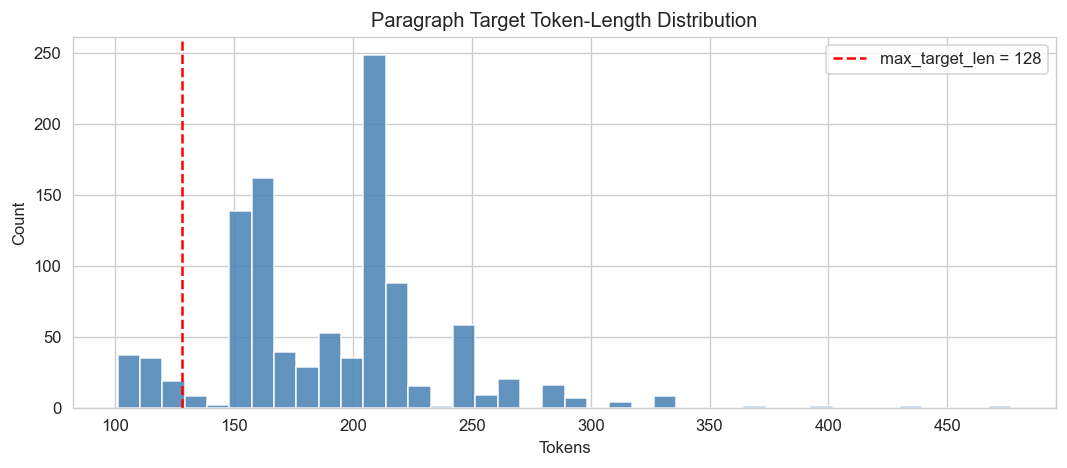

In [40]:
# ============================================================
#  Step 4 — Tokeniser & Token-Length Inspection
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(CONFIG['llm_model'])

lengths = np.array([
    len(tokenizer(t, truncation=False)['input_ids'])
    for t in merged['target_text']
])

print(f'Token-length stats  min={lengths.min()}  max={lengths.max()}  '
      f'mean={lengths.mean():.1f}  p95={np.percentile(lengths, 95):.0f}')
print(f'Exceeding max_target_len: {(lengths > CONFIG["max_target_len"]).sum()}')

plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(CONFIG['max_target_len'], color='red', ls='--', lw=1.5,
            label=f'max_target_len = {CONFIG["max_target_len"]}')
plt.xlabel('Tokens')
plt.ylabel('Count')
plt.title('Paragraph Target Token-Length Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
#  Step 5 — Train / Val Split
# ============================================================

indices = np.arange(len(merged))

train_idx, val_idx = train_test_split(
    indices,
    test_size=CONFIG['val_ratio'],
    random_state=SEED,
)
print(f'Train: {len(train_idx)}  |  Val: {len(val_idx)}')

Train: 881  |  Val: 156


In [42]:
# ============================================================
#  Step 6 — Quadrimodal Dataset
# ============================================================

class QuadrimodalProteinDataset(Dataset):
    """
    Four-modality dataset: seq + sbert + tfidf + msa.
    Independent modality-dropout applied to sbert, tfidf, and msa.
    """

    def __init__(self, seq_embs, sbert_embs, tfidf_embs, msa_embs,
                 target_texts, tokenizer, max_len=200,
                 sbert_drop=0.0, tfidf_drop=0.0, msa_drop=0.0, training=True):
        self.seq   = torch.tensor(seq_embs,   dtype=torch.float32)
        self.sbert = torch.tensor(sbert_embs, dtype=torch.float32)
        self.tfidf = torch.tensor(tfidf_embs, dtype=torch.float32)
        self.msa   = torch.tensor(msa_embs,   dtype=torch.float32)
        self.texts  = target_texts
        self.tok    = tokenizer
        self.max_len     = max_len
        self.sbert_drop  = sbert_drop
        self.tfidf_drop  = tfidf_drop
        self.msa_drop    = msa_drop
        self.training    = training

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        seq   = self.seq[idx]
        sbert = self.sbert[idx].clone()
        tfidf = self.tfidf[idx].clone()
        msa   = self.msa[idx].clone()

        if self.training:
            if self.sbert_drop > 0 and random.random() < self.sbert_drop:
                sbert = torch.zeros_like(sbert)
            if self.tfidf_drop > 0 and random.random() < self.tfidf_drop:
                tfidf = torch.zeros_like(tfidf)
            if self.msa_drop > 0 and random.random() < self.msa_drop:
                msa = torch.zeros_like(msa)

        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        labels = enc['input_ids'].squeeze(0)
        labels[labels == self.tok.pad_token_id] = -100

        return {'seq': seq, 'sbert': sbert, 'tfidf': tfidf,
                'msa': msa, 'labels': labels}


def make_loaders(batch_size, training=True):
    tr = QuadrimodalProteinDataset(
        seq_embeddings[train_idx],   sbert_embeddings[train_idx],
        tfidf_embeddings[train_idx], msa_embeddings[train_idx],
        merged.iloc[train_idx]['target_text'].tolist(),
        tokenizer, max_len=CONFIG['max_target_len'],
        sbert_drop=CONFIG['sbert_dropout'] if training else 0.0,
        tfidf_drop=CONFIG['tfidf_dropout'] if training else 0.0,
        msa_drop=CONFIG['msa_dropout']     if training else 0.0,
        training=training,
    )
    va = QuadrimodalProteinDataset(
        seq_embeddings[val_idx],   sbert_embeddings[val_idx],
        tfidf_embeddings[val_idx], msa_embeddings[val_idx],
        merged.iloc[val_idx]['target_text'].tolist(),
        tokenizer, max_len=CONFIG['max_target_len'],
        training=False,
    )
    return (
        DataLoader(tr, batch_size=batch_size, shuffle=True,  num_workers=0),
        DataLoader(va, batch_size=batch_size, shuffle=False, num_workers=0),
    )


sample_loader, _ = make_loaders(4)
sample_batch = next(iter(sample_loader))
for k, v in sample_batch.items():
    print(f'  {k:<8s}: {v.shape}')

  seq     : torch.Size([4, 1280])
  sbert   : torch.Size([4, 384])
  tfidf   : torch.Size([4, 128])
  msa     : torch.Size([4, 64])
  labels  : torch.Size([4, 128])


In [43]:
# ============================================================
#  Model: Four Projectors + Flan-T5-small + LoRA
# ============================================================

class ModalityProjector(nn.Module):
    """MLP: input_dim → N soft tokens of size hidden_dim."""

    def __init__(self, input_dim, hidden_dim, num_tokens):
        super().__init__()
        self.num_tokens = num_tokens
        self.hidden_dim = hidden_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.GELU(),
            nn.LayerNorm(hidden_dim * 2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim * num_tokens),
        )
        self.ln = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        h = self.net(x).view(-1, self.num_tokens, self.hidden_dim)
        return self.ln(h)


class QuadrimodalProt2Text(nn.Module):
    """
    Four projectors:
      ESM2-seq (8 tokens) + SBERT (4) + TF-IDF (4) + MSA (4) = 20 soft tokens
    Flan-T5-small decoder (LoRA) cross-attends to these and
    generates a single-paragraph description of the protein.
    """

    def __init__(self, cfg):
        super().__init__()
        self.t5 = T5ForConditionalGeneration.from_pretrained(cfg['llm_model'])
        D = self.t5.config.d_model  # 512 for flan-t5-small

        self.seq_proj   = ModalityProjector(cfg['seq_embedding_dim'],   D, cfg['num_seq_tokens'])
        self.sbert_proj = ModalityProjector(cfg['sbert_embedding_dim'], D, cfg['num_sbert_tokens'])
        self.tfidf_proj = ModalityProjector(cfg['tfidf_embedding_dim'], D, cfg['num_tfidf_tokens'])
        self.msa_proj   = ModalityProjector(cfg['msa_embedding_dim'],   D, cfg['num_msa_tokens'])

        self.total_tokens = (cfg['num_seq_tokens'] + cfg['num_sbert_tokens'] +
                             cfg['num_tfidf_tokens'] + cfg['num_msa_tokens'])

        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_2_SEQ_LM,
            r=cfg['lora_r'], lora_alpha=cfg['lora_alpha'],
            lora_dropout=cfg['lora_dropout'],
            target_modules=['q', 'v'],
            inference_mode=False,
        )
        self.t5 = get_peft_model(self.t5, lora_cfg)

    def _encode(self, seq, sbert, tfidf, msa):
        h = torch.cat([
            self.seq_proj(seq),
            self.sbert_proj(sbert),
            self.tfidf_proj(tfidf),
            self.msa_proj(msa),
        ], dim=1)   # (B, 20, 512)
        mask = torch.ones(h.size(0), self.total_tokens,
                          dtype=torch.long, device=h.device)
        return BaseModelOutput(last_hidden_state=h), mask

    def forward(self, seq, sbert, tfidf, msa, labels=None):
        enc, mask = self._encode(seq, sbert, tfidf, msa)
        return self.t5(encoder_outputs=enc, attention_mask=mask, labels=labels)

    @torch.no_grad()
    def generate(self, seq, sbert, tfidf, msa, tokenizer,
                 max_length=128, num_beams=2):
        """Generate a paragraph description.  num_beams=2 default for CPU."""
        self.eval()
        enc, mask = self._encode(seq, sbert, tfidf, msa)
        ids = self.t5.generate(
            encoder_outputs=enc, attention_mask=mask,
            max_length=max_length, num_beams=num_beams,
            early_stopping=True, no_repeat_ngram_size=3,
        )
        return tokenizer.batch_decode(ids, skip_special_tokens=True)


model = QuadrimodalProt2Text(CONFIG).to(DEVICE)

print('=' * 60)
print('  MODEL SUMMARY')
print('=' * 60)
model.t5.print_trainable_parameters()
for name, proj in [('Seq',   model.seq_proj),
                   ('SBERT', model.sbert_proj),
                   ('TFIDF', model.tfidf_proj),
                   ('MSA',   model.msa_proj)]:
    n = sum(p.numel() for p in proj.parameters())
    print(f'  {name:<6s} projector : {n:,} params')
print(f'  Total soft tokens : {model.total_tokens}')
print(f'  Device            : {DEVICE}')

  MODEL SUMMARY
trainable params: 344,064 || all params: 77,305,216 || trainable%: 0.4451
  Seq    projector : 5,513,216 params
  SBERT  projector : 2,496,512 params
  TFIDF  projector : 2,234,368 params
  MSA    projector : 2,168,832 params
  Total soft tokens : 20
  Device            : cpu


In [44]:
# ============================================================
#  Step 8 — Warm Start from V2 Saved Weights (seq + sbert)
# ============================================================

v2_dir = CONFIG['v2_output_dir']
proj_path = os.path.join(v2_dir, 'projectors_final_v2.pt')

if os.path.exists(proj_path):
    v2_proj = torch.load(proj_path, map_location=DEVICE, weights_only=True)

    # Seq projector — same input dim (1280), should load cleanly
    try:
        model.seq_proj.load_state_dict(v2_proj['seq_projector'])
        print('Loaded V2 seq projector')
    except RuntimeError as e:
        print(f'Seq projector mismatch (training from scratch): {e}')

    # SBERT projector — same input dim (384)
    try:
        model.sbert_proj.load_state_dict(v2_proj['text_projector'])
        print('Loaded V2 sbert projector (from text_projector)')
    except RuntimeError as e:
        print(f'SBERT projector mismatch (training from scratch): {e}')
else:
    print(f'No V2 projectors found at {proj_path} — training all from scratch')

# Load V2 LoRA weights
lora_dir = os.path.join(v2_dir, 't5_lora_best_v2')
if os.path.exists(lora_dir):
    try:
        from safetensors.torch import load_file as load_st
        v2_lora = load_st(os.path.join(lora_dir, 'adapter_model.safetensors'))
        model_sd = model.t5.state_dict()
        loaded = 0
        for k, v in v2_lora.items():
            if k in model_sd and v.shape == model_sd[k].shape:
                model_sd[k] = v
                loaded += 1
        model.t5.load_state_dict(model_sd, strict=False)
        print(f'Loaded V2 LoRA weights ({loaded} / {len(v2_lora)} tensors)')
    except Exception as e:
        print(f'LoRA warm-start skipped: {e}')
else:
    print(f'No V2 LoRA directory found — training LoRA from scratch')

print('\nTF-IDF and MSA projectors will train from scratch (new modalities)')

Seq projector mismatch (training from scratch): Error(s) in loading state_dict for ModalityProjector:
	Missing key(s) in state_dict: "ln.weight", "ln.bias". 
	Unexpected key(s) in state_dict: "layer_norm.weight", "layer_norm.bias". 
SBERT projector mismatch (training from scratch): Error(s) in loading state_dict for ModalityProjector:
	Missing key(s) in state_dict: "ln.weight", "ln.bias". 
	Unexpected key(s) in state_dict: "layer_norm.weight", "layer_norm.bias". 
Loaded V2 LoRA weights (0 / 96 tensors)

TF-IDF and MSA projectors will train from scratch (new modalities)


In [45]:
# ============================================================
#  Training Utilities
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, device, epoch, tag):
    model.train()
    total, n = 0.0, 0
    for i, batch in enumerate(loader):
        seq   = batch['seq'].to(device)
        sbert = batch['sbert'].to(device)
        tfidf = batch['tfidf'].to(device)
        msa   = batch['msa'].to(device)
        lbl   = batch['labels'].to(device)

        loss = model(seq, sbert, tfidf, msa, labels=lbl).loss
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total += loss.item()
        n += 1
        if (i + 1) % CONFIG['log_every'] == 0:
            print(f'    [{tag}] epoch {epoch+1} | batch {i+1}/{len(loader)} | loss {loss.item():.4f}')
    return total / max(n, 1)


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        seq   = batch['seq'].to(device)
        sbert = batch['sbert'].to(device)
        tfidf = batch['tfidf'].to(device)
        msa   = batch['msa'].to(device)
        lbl   = batch['labels'].to(device)
        total += model(seq, sbert, tfidf, msa, labels=lbl).loss.item()
        n += 1
    return total / max(n, 1)


print('Training utilities ready')

Training utilities ready


In [46]:
# ============================================================
#  Training — All Projectors + LoRA  (single stage, CPU mode)
#
#  seq + sbert projectors are warm-started from V2 weights
#  (loaded in the cell above).  tfidf + msa projectors start
#  from random init.  LoRA adapters are also warm-started from V2.
# ============================================================

print('  TRAINING — All Projectors + LoRA  (single stage)')
print('=' * 60)

total = sum(p.numel() for p in model.parameters())

# Unfreeze LoRA + all four projectors, keep base T5 weights frozen
for name, p in model.t5.named_parameters():
    p.requires_grad = 'lora' in name.lower()
for proj in [model.seq_proj, model.sbert_proj, model.tfidf_proj, model.msa_proj]:
    for p in proj.parameters():
        p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')
print(f'  Device   : {DEVICE}')
print(f'  Batch    : {CONFIG["train_batch"]}  |  Epochs: {CONFIG["train_epochs"]}')
print(f'  LoRA r   : {CONFIG["lora_r"]}  |  LR: {CONFIG["train_lr"]}')

tr_loader, va_loader = make_loaders(CONFIG['train_batch'])

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG['train_lr'], weight_decay=0.01,
)
total_steps = len(tr_loader) * CONFIG['train_epochs']
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * total_steps)),
    num_training_steps=total_steps,
)

hist_training = {'train': [], 'val': []}
best_val      = float('inf')
pat_ctr       = 0

for ep in range(CONFIG['train_epochs']):
    tr_loss = train_epoch(model, tr_loader, optimizer, scheduler, DEVICE, ep, 'Train')
    va_loss = eval_epoch(model, va_loader, DEVICE)
    hist_training['train'].append(tr_loss)
    hist_training['val'].append(va_loss)

    marker = ''
    if va_loss < best_val:
        best_val = va_loss
        pat_ctr  = 0
        torch.save({
            'seq_proj':   model.seq_proj.state_dict(),
            'sbert_proj': model.sbert_proj.state_dict(),
            'tfidf_proj': model.tfidf_proj.state_dict(),
            'msa_proj':   model.msa_proj.state_dict(),
            'epoch': ep, 'val_loss': va_loss,
        }, os.path.join(CONFIG['output_dir'], 'best_model.pt'))
        model.t5.save_pretrained(os.path.join(CONFIG['output_dir'], 't5_lora_best'))
        marker = '  ✓ saved'
    else:
        pat_ctr += 1

    print(f'  Epoch {ep+1}/{CONFIG["train_epochs"]}  '
          f'train={tr_loss:.4f}  val={va_loss:.4f}{marker}')

    if pat_ctr >= CONFIG['patience']:
        print(f'  Early stopping at epoch {ep+1} (patience={CONFIG["patience"]})')
        break

print(f'\nTraining done — best val loss: {best_val:.4f}')

  TRAINING — All Projectors + LoRA  (single stage)
  Trainable: 12,756,992 / 89,718,144 (14.22%)
  Device   : cpu
  Batch    : 4  |  Epochs: 5
  LoRA r   : 8  |  LR: 0.003
    [Train] epoch 1 | batch 10/221 | loss 10.7521
    [Train] epoch 1 | batch 20/221 | loss 12.2669
    [Train] epoch 1 | batch 30/221 | loss 13.1165
    [Train] epoch 1 | batch 40/221 | loss 9.1625
    [Train] epoch 1 | batch 50/221 | loss 8.3610
    [Train] epoch 1 | batch 60/221 | loss 7.5364
    [Train] epoch 1 | batch 70/221 | loss 6.4763
    [Train] epoch 1 | batch 80/221 | loss 7.0064
    [Train] epoch 1 | batch 90/221 | loss 6.3358
    [Train] epoch 1 | batch 100/221 | loss 5.9187
    [Train] epoch 1 | batch 110/221 | loss 5.7251
    [Train] epoch 1 | batch 120/221 | loss 5.8544
    [Train] epoch 1 | batch 130/221 | loss 5.6311
    [Train] epoch 1 | batch 140/221 | loss 5.2670
    [Train] epoch 1 | batch 150/221 | loss 5.5599
    [Train] epoch 1 | batch 160/221 | loss 5.5278
    [Train] epoch 1 | batch 170/22

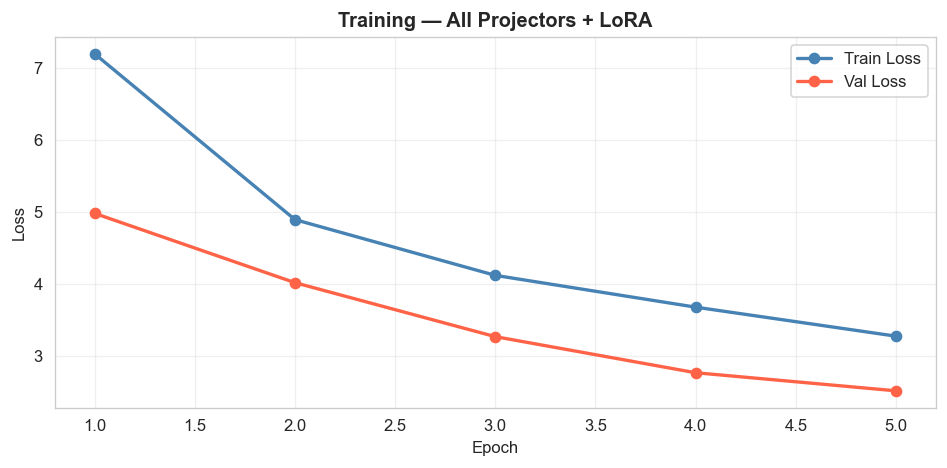

Training curve saved


In [47]:
# ── Training Curve ──

fig, ax = plt.subplots(figsize=(8, 4))
eps = range(1, len(hist_training['train']) + 1)
ax.plot(eps, hist_training['train'], 'o-', color='steelblue', label='Train Loss', lw=2)
ax.plot(eps, hist_training['val'],   'o-', color='tomato',    label='Val Loss',   lw=2)
ax.set_title('Training — All Projectors + LoRA', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_curve.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Training curve saved')

In [48]:
# ============================================================
#  Evaluation: BLEU, ROUGE & Sample Paragraphs
# ============================================================

# Load best checkpoint
best_ckpt = torch.load(
    os.path.join(CONFIG['output_dir'], 'best_model.pt'),
    map_location=DEVICE, weights_only=True,
)
model.seq_proj.load_state_dict(best_ckpt['seq_proj'])
model.sbert_proj.load_state_dict(best_ckpt['sbert_proj'])
model.tfidf_proj.load_state_dict(best_ckpt['tfidf_proj'])
model.msa_proj.load_state_dict(best_ckpt['msa_proj'])
print(f'Loaded best model — epoch {best_ckpt["epoch"]+1}, val_loss={best_ckpt["val_loss"]:.4f}')

# Generate on validation set (greedy-ish with num_beams=2 for CPU speed)
model.eval()
v_seq   = torch.tensor(seq_embeddings[val_idx],   dtype=torch.float32).to(DEVICE)
v_sbert = torch.tensor(sbert_embeddings[val_idx], dtype=torch.float32).to(DEVICE)
v_tfidf = torch.tensor(tfidf_embeddings[val_idx], dtype=torch.float32).to(DEVICE)
v_msa   = torch.tensor(msa_embeddings[val_idx],   dtype=torch.float32).to(DEVICE)
v_gt    = merged.iloc[val_idx]['target_text'].tolist()

generated = []
B = CONFIG['train_batch']
print(f'Generating {len(val_idx)} validation paragraphs (num_beams={CONFIG["num_beams"]})...')
for i in range(0, len(val_idx), B):
    preds = model.generate(
        v_seq[i:i+B], v_sbert[i:i+B], v_tfidf[i:i+B], v_msa[i:i+B],
        tokenizer,
        max_length=CONFIG['max_target_len'],
        num_beams=CONFIG['num_beams'],
    )
    generated.extend(preds)

print(f'Done — {len(generated)} paragraphs generated')

# Metrics
bleu  = evaluate.load('bleu').compute(predictions=generated, references=[[r] for r in v_gt])
rouge = evaluate.load('rouge').compute(predictions=generated, references=v_gt)

print('\n' + '=' * 55)
print('  EVALUATION METRICS')
print('=' * 55)
print(f'  BLEU       : {bleu["bleu"]:.4f}')
for i, p in enumerate(bleu['precisions']):
    print(f'  BLEU-{i+1}     : {p:.4f}')
print(f'  ROUGE-1    : {rouge["rouge1"]:.4f}')
print(f'  ROUGE-2    : {rouge["rouge2"]:.4f}')
print(f'  ROUGE-L    : {rouge["rougeL"]:.4f}')

metrics_out = {
    'bleu': bleu['bleu'],
    **{f'bleu_{i+1}': bleu['precisions'][i] for i in range(4)},
    **{k: v for k, v in rouge.items()},
}
with open(os.path.join(CONFIG['output_dir'], 'eval_metrics.json'), 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('\n  Metrics saved to eval_metrics.json')

# ── Show 5 sample paragraphs ──
np.random.seed(SEED)
for k, idx in enumerate(np.random.choice(len(generated), size=5, replace=False)):
    row = merged.iloc[val_idx[idx]]
    print(f'\n{"═"*70}')
    print(f'  Example {k+1} | {row["ID"]} | {row["subfamily"]}')
    print(f'{"═"*70}')
    print(f'  REFERENCE : {v_gt[idx]}')
    print(f'\n  GENERATED : {generated[idx]}')

Loaded best model — epoch 5, val_loss=2.5200
Generating 156 validation paragraphs (num_beams=2)...
Done — 156 paragraphs generated

  EVALUATION METRICS
  BLEU       : 0.0629
  BLEU-1     : 0.4753
  BLEU-2     : 0.2091
  BLEU-3     : 0.0748
  BLEU-4     : 0.0274
  ROUGE-1    : 0.3961
  ROUGE-2    : 0.1556
  ROUGE-L    : 0.2649

  Metrics saved to eval_metrics.json

══════════════════════════════════════════════════════════════════════
  Example 1 | K7G2Y8 | Other_ClassA
══════════════════════════════════════════════════════════════════════
  REFERENCE : 5-hydroxytryptamine receptor 6, a G protein-coupled receptor, functions as g-protein coupled receptor for 5-hydroxytryptamine (serotonin), a biogenic hormone that functions as a neurotransmitter, a hormone and a mitogen. Also has a high affinity for tricyclic psychotropic drugs. Ligand binding causes a conformation change that triggers signaling via guanine nucleotide-binding proteins (G proteins) and modulates the activity of downstrea

In [49]:
# ============================================================
#  Inference on Unlabeled Proteins (Sequence-Only Mode)
#
#  For proteins that have no text metadata, zeroes are passed
#  for SBERT / TF-IDF / MSA.  The model learned to handle this
#  gracefully via modality dropout during training.
# ============================================================

unlabeled_path = '../data/processed/data_esm2_mean_pooling_without_id.csv'

if os.path.exists(unlabeled_path):
    ul_df = pd.read_csv(unlabeled_path)
    print(f'Unlabeled embeddings: {ul_df.shape}')

    if 'uniref_id' in ul_df.columns:
        ul_ids = ul_df['uniref_id'].tolist()
        ul_df  = ul_df.drop(columns=['uniref_id'])
    elif 'Unnamed: 0' in ul_df.columns:
        ul_ids = ul_df['Unnamed: 0'].tolist()
        ul_df  = ul_df.drop(columns=['Unnamed: 0'])
    else:
        ul_ids = [f'seq_{i}' for i in range(len(ul_df))]

    ul_embs = ul_df.values.astype(np.float32)

    model.eval()
    all_preds = []
    B = CONFIG['train_batch']
    print(f'Generating for {len(ul_embs)} proteins (sequence-only, num_beams={CONFIG["num_beams"]})...')
    for i in range(0, len(ul_embs), B):
        s = torch.tensor(ul_embs[i:i+B], dtype=torch.float32).to(DEVICE)
        n = s.size(0)
        z_sb = torch.zeros(n, CONFIG['sbert_embedding_dim'], dtype=torch.float32).to(DEVICE)
        z_tf = torch.zeros(n, CONFIG['tfidf_embedding_dim'], dtype=torch.float32).to(DEVICE)
        z_ms = torch.zeros(n, CONFIG['msa_embedding_dim'],   dtype=torch.float32).to(DEVICE)
        texts = model.generate(s, z_sb, z_tf, z_ms, tokenizer,
                               max_length=CONFIG['max_target_len'],
                               num_beams=CONFIG['num_beams'])
        all_preds.extend(texts)
        if (i // B + 1) % 25 == 0:
            print(f'  Processed {min(i+B, len(ul_embs))}/{len(ul_embs)}')

    unlabeled_results = pd.DataFrame({
        'ID':             ul_ids[:len(all_preds)],
        'generated_text': all_preds,
    })
    unlabeled_results.to_csv(
        os.path.join(CONFIG['output_dir'], 'unlabeled_predictions.csv'), index=False
    )
    print(f'\nSaved {len(unlabeled_results)} predictions')

    for idx in [0, len(all_preds)//2, -1]:
        print(f'\n{"─"*70}')
        print(f'  {ul_ids[idx]}')
        print(f'  {all_preds[idx][:300]}')
else:
    print(f'Unlabeled file not found: {unlabeled_path}')

Unlabeled embeddings: (961, 1281)
Generating for 961 proteins (sequence-only, num_beams=2)...
  Processed 100/961
  Processed 200/961
  Processed 300/961
  Processed 400/961
  Processed 500/961
  Processed 600/961
  Processed 700/961
  Processed 800/961
  Processed 900/961

Saved 961 predictions

──────────────────────────────────────────────────────────────────────
  P07550
  Betaergic ae-a protein-led receptor receptor receptor, a proteining, coupled receptor signal-coupled in signaling signal-duction via G protein-a role receptor signal transcoupled signal-a a role in signal transa protein transcoupergic receptor signaling in signal-involving plasma processes-a partici

──────────────────────────────────────────────────────────────────────
  UPI00094F375C
  Betaergic a G protein-coupled receptor receptor receptor signal-a protein-led receptor signal transcoupled in signal-duction via G proteining signaling signal-involving plasma processes-duction G protein transduction via receptor

Encoding generated paragraphs with SBERT...


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

SBERT embeddings: (961, 384)

UMAP 50-d...
HDBSCAN clustering...
UMAP 2-d for visualisation...

Clusters : 60  |  Noise : 45 (4.7%)
Silhouette       : 0.7474
Davies-Bouldin   : 0.3176


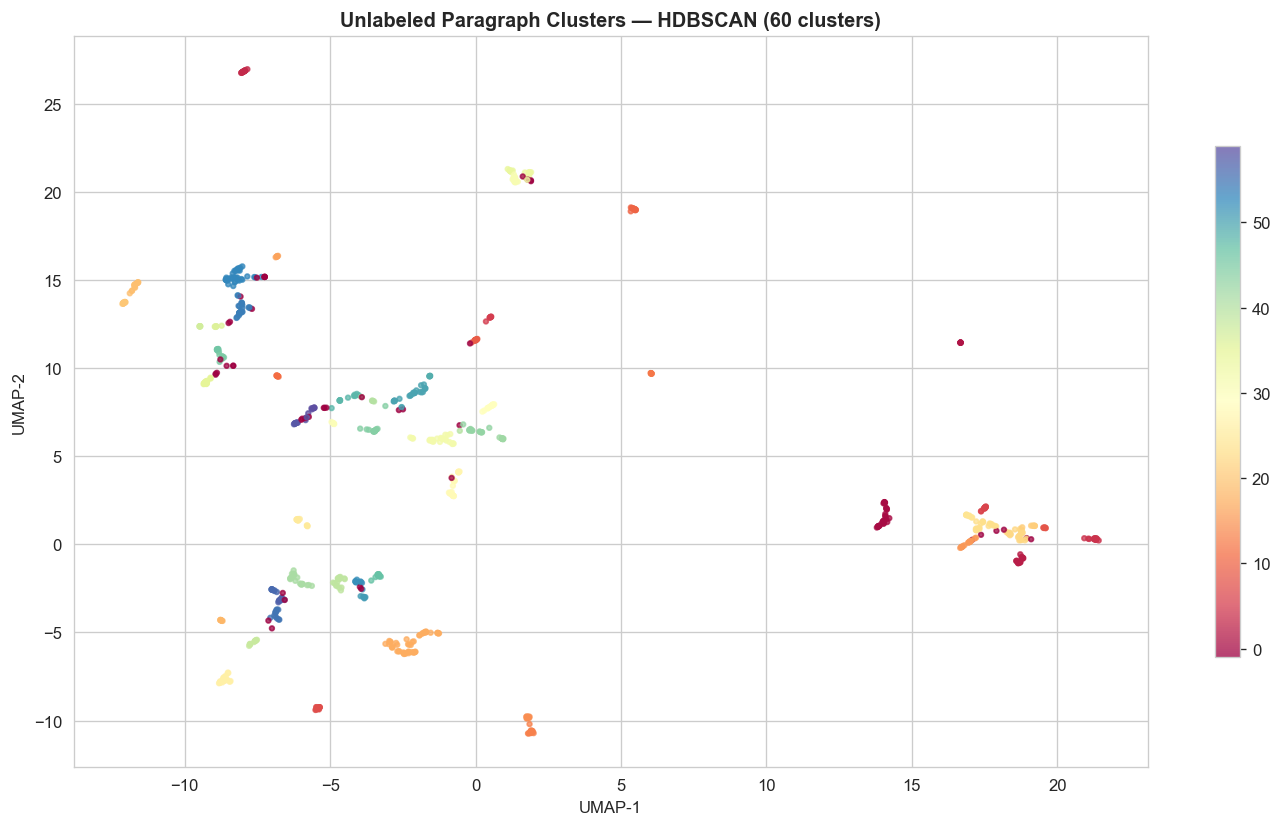

Clustering plot saved


In [50]:
# ============================================================
#  Step 11 — Cluster Unlabeled Paragraphs
#  SBERT → UMAP (50-d) → HDBSCAN → UMAP (2-d) plot
# ============================================================

from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import silhouette_score, davies_bouldin_score

print('Encoding generated paragraphs with SBERT...')
sbert_cluster_model = SentenceTransformer('all-MiniLM-L6-v2')
gen_texts_list = unlabeled_results['generated_text'].tolist()
gen_embs = sbert_cluster_model.encode(
    gen_texts_list, show_progress_bar=True, batch_size=32
)
print(f'SBERT embeddings: {gen_embs.shape}')

print('\nUMAP 50-d...')
umap50 = umap.UMAP(n_components=50, random_state=SEED, metric='cosine')
emb50  = umap50.fit_transform(gen_embs)

print('HDBSCAN clustering...')
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5, metric='euclidean')
labels    = clusterer.fit_predict(emb50)

print('UMAP 2-d for visualisation...')
umap2d = umap.UMAP(n_components=2, random_state=SEED, metric='cosine')
emb2d  = umap2d.fit_transform(gen_embs)

unlabeled_results['cluster'] = labels
unlabeled_results['umap_x']  = emb2d[:, 0]
unlabeled_results['umap_y']  = emb2d[:, 1]

n_cl    = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f'\nClusters : {n_cl}  |  Noise : {n_noise} ({100*n_noise/len(labels):.1f}%)')

# Cluster quality metrics
non_noise = labels != -1
if non_noise.sum() > 1:
    sil = silhouette_score(emb50[non_noise], labels[non_noise])
    db  = davies_bouldin_score(emb50[non_noise], labels[non_noise])
    print(f'Silhouette       : {sil:.4f}')
    print(f'Davies-Bouldin   : {db:.4f}')

# Save
unlabeled_results.to_csv(
    os.path.join(CONFIG['output_dir'], 'clustered_predictions.csv'), index=False
)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(emb2d[:, 0], emb2d[:, 1],
                c=labels, cmap='Spectral', s=8, alpha=0.75)
ax.set_title(f'Unlabeled Paragraph Clusters — HDBSCAN ({n_cl} clusters)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.colorbar(sc, ax=ax, shrink=0.7)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'clustering.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Clustering plot saved')

In [51]:
# ============================================================
#  Save All Artifacts
# ============================================================

torch.save({
    'seq_proj':   model.seq_proj.state_dict(),
    'sbert_proj': model.sbert_proj.state_dict(),
    'tfidf_proj': model.tfidf_proj.state_dict(),
    'msa_proj':   model.msa_proj.state_dict(),
}, os.path.join(CONFIG['output_dir'], 'projectors_final.pt'))

model.t5.save_pretrained(os.path.join(CONFIG['output_dir'], 't5_lora_final'))
tokenizer.save_pretrained(os.path.join(CONFIG['output_dir'], 'tokenizer'))

# Save dimension-reduction transforms so they can be reused at inference
import pickle
with open(os.path.join(CONFIG['output_dir'], 'tfidf_svd.pkl'), 'wb') as f:
    pickle.dump(svd, f)
with open(os.path.join(CONFIG['output_dir'], 'msa_pca.pkl'), 'wb') as f:
    pickle.dump(pca_msa, f)

with open(os.path.join(CONFIG['output_dir'], 'config.json'), 'w') as f:
    json.dump(CONFIG, f, indent=2)
with open(os.path.join(CONFIG['output_dir'], 'training_history.json'), 'w') as f:
    json.dump(hist_training, f, indent=2)

print('=' * 55)
print('  SAVED ARTIFACTS')
print('=' * 55)
for name in sorted(os.listdir(CONFIG['output_dir'])):
    full = os.path.join(CONFIG['output_dir'], name)
    if os.path.isfile(full):
        mb = os.path.getsize(full) / 1e6
        print(f'  {name:<45s} {mb:>7.2f} MB')
    else:
        print(f'  {name + "/":<45s} (dir)')

  SAVED ARTIFACTS
  best_model.pt                                   49.66 MB
  clustered_predictions.csv                        0.54 MB
  clustering.png                                   0.21 MB
  config.json                                      0.00 MB
  eval_metrics.json                                0.00 MB
  msa_pca.pkl                                      0.27 MB
  projectors_final.pt                             49.66 MB
  t5_lora_best/                                 (dir)
  t5_lora_final/                                (dir)
  tfidf_svd.pkl                                    0.53 MB
  tokenizer/                                    (dir)
  training_curve.png                               0.05 MB
  training_history.json                            0.00 MB
  unlabeled_predictions.csv                        0.52 MB


---

## Summary

| Item | Detail |
|------|--------|
| **Architecture** | Quadrimodal — 4 projectors → 20 soft tokens → Flan-T5-small (LoRA) |
| **ESM2** | Absolute sequence representation (biochemistry of amino acids) → 8 tokens |
| **SBERT** | Semantic text meaning → 4 tokens |
| **TF-IDF/LSA** | Keyword/GO vocabulary bag-of-words → 128-d → 4 tokens |
| **MSA** | Relational evolutionary neighbourhood (pairwise cosine similarity profile) → 64-d PCA → 4 tokens |
| **ESM2 vs MSA** | ESM2 = *what this protein is*; MSA = *where it sits in the family tree* — orthogonal views |
| **Output format** | Single natural-language paragraph per protein |
| **Training** | Single stage — all projectors + LoRA together; seq+SBERT warm-started from V2 |
| **CPU settings** | batch=4, epochs=3, lora_r=8, max_len=128, num_beams=2, patience=3 |
| **Modality dropout** | 20% each for SBERT, TF-IDF, MSA independently → robust sequence-only inference |
| **Output dir** | `prot2func_gpcr_output_v2_msa/` |